In [3]:
import pandas as pd
import plotly.express as px


In [5]:
suministroAgua2008_2010=pd.read_csv('../data/SuministroDiarioDeAguaConeval/SIDS_AE Vi-1 RESULTADOS.csv',encoding='latin-1',usecols=[0,1], skiprows=1)
suministroAgua2012_2014=pd.read_csv('../data/SuministroDiarioDeAguaConeval/SIDS_AE Vi-1 RESULTADOS (1).csv',encoding='latin-1',usecols=[1,2],skiprows=1)
suministroAgua2016_2018=pd.read_csv('../data/SuministroDiarioDeAguaConeval/SIDS_AE Vi-1 RESULTADOS (2).csv',encoding='latin-1',usecols=[1,2],skiprows=1)
suministroAgua2020_2022=pd.read_csv('../data/SuministroDiarioDeAguaConeval/SIDS_AE Vi-1 RESULTADOS (3).csv',encoding='latin-1',usecols=[1,2],skiprows=1)

suministro_total = pd.concat([
    suministroAgua2008_2010.reset_index(drop=True),
    suministroAgua2012_2014.reset_index(drop=True),
    suministroAgua2016_2018.reset_index(drop=True),
    suministroAgua2020_2022.reset_index(drop=True)
], axis=1)
suministro_total=suministro_total.drop([33,34,35,36,37])
suministro_total

,Entidad,2008,2012,2014,2016,2018,2020,2022
0,Aguascalientes,90.259341,87.973873,83.612526,88.228302,87.795055,82.501699,79.870160
1,Baja California,88.733682,88.263897,81.311992,86.310814,84.086361,87.577967,89.402182
2,Baja California Sur,44.190183,50.519383,25.980949,23.386389,19.040462,17.227671,21.188654
3,Campeche,41.914509,49.961139,45.026233,54.655881,50.739647,55.022463,47.460569
4,Coahuila,70.192819,64.465088,70.156050,69.042698,73.363477,75.764865,71.723230
5,Colima,86.041098,83.917917,83.846406,83.152164,81.308398,82.820804,81.765944
6,Chiapas,14.404374,15.251299,10.947973,9.246656,12.549663,14.375526,10.550023
7,Chihuahua,83.736222,86.994873,85.968306,87.299295,89.352344,88.180311,90.999942
8,Ciudad de México,72.097164,69.666024,73.618802,70.538816,67.747348,73.543868,72.299000
9,Durango,64.771339,61.941139,72.952830,72.862592,72.793644,75.609462,71.238343


Datos transformados:
               Entidad   Año  Porcentaje
0       Aguascalientes  2008   90.259341
1      Baja California  2008   88.733682
2  Baja California Sur  2008   44.190183
3             Campeche  2008   41.914509
4             Coahuila  2008   70.192819

Años disponibles: [np.int64(2008), np.int64(2012), np.int64(2014), np.int64(2016), np.int64(2018), np.int64(2020), np.int64(2022)]
Entidades: 33


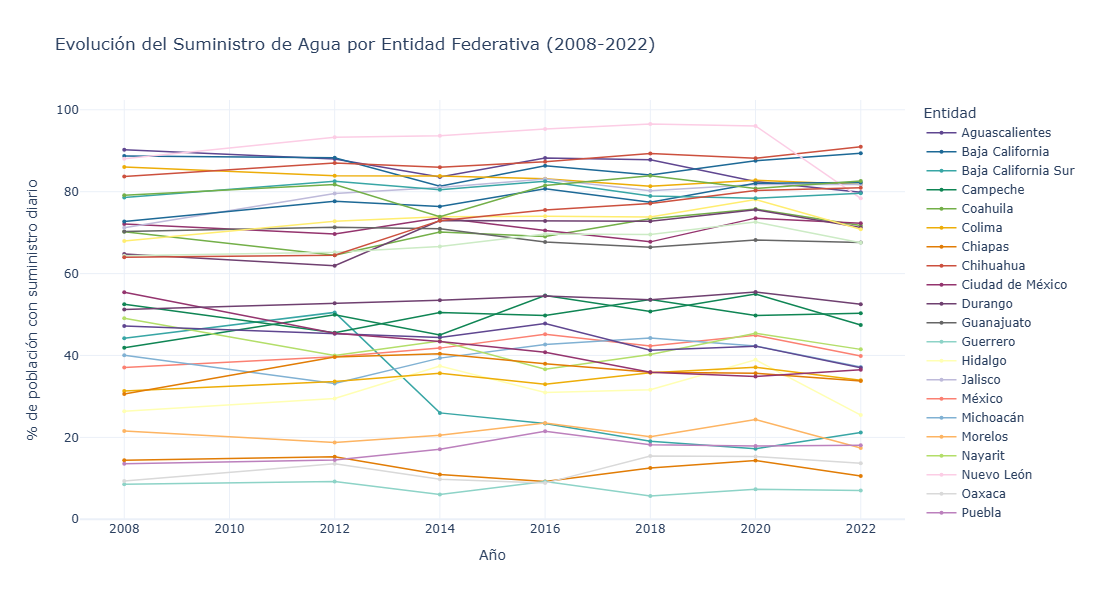

In [159]:
colores = px.colors.qualitative.Prism + px.colors.qualitative.Set3
df_tidy = pd.melt(
    suministro_total,  
    id_vars=['Entidad'],
    var_name='Año', 
    value_name='Porcentaje'
)
df_tidy['Año'] = df_tidy['Año'].astype(int)

# Verificar que funcionó
print("Datos transformados:")
print(df_tidy.head())
print(f"\nAños disponibles: {sorted(df_tidy['Año'].unique())}")
print(f"Entidades: {df_tidy['Entidad'].nunique()}")

# Crear gráfico de líneas
fig = px.line(
    df_tidy, 
    x='Año', 
    y='Porcentaje', 
    color='Entidad',
    color_discrete_sequence=colores,
    title='Evolución del Suministro de Agua por Entidad Federativa (2008-2022)',
    labels={'Porcentaje': '% de población con suministro diario', 'Año': 'Año'},
    template='plotly_white'
)

# Mejorar visualización
fig.update_traces(mode='lines+markers', marker=dict(size=4), line=dict(width=1.5))
fig.update_layout(
    height=600,
    hovermode='x unified',
    legend=dict(
        title='Entidad',
        orientation='v',
        yanchor='top',
        y=1,
        xanchor='left',
        x=1.02
    )
)

# Mostrar gráfica
fig.show()

# Guardar como HTML interactivo
fig.write_html('grafica_suministro_agua.html')

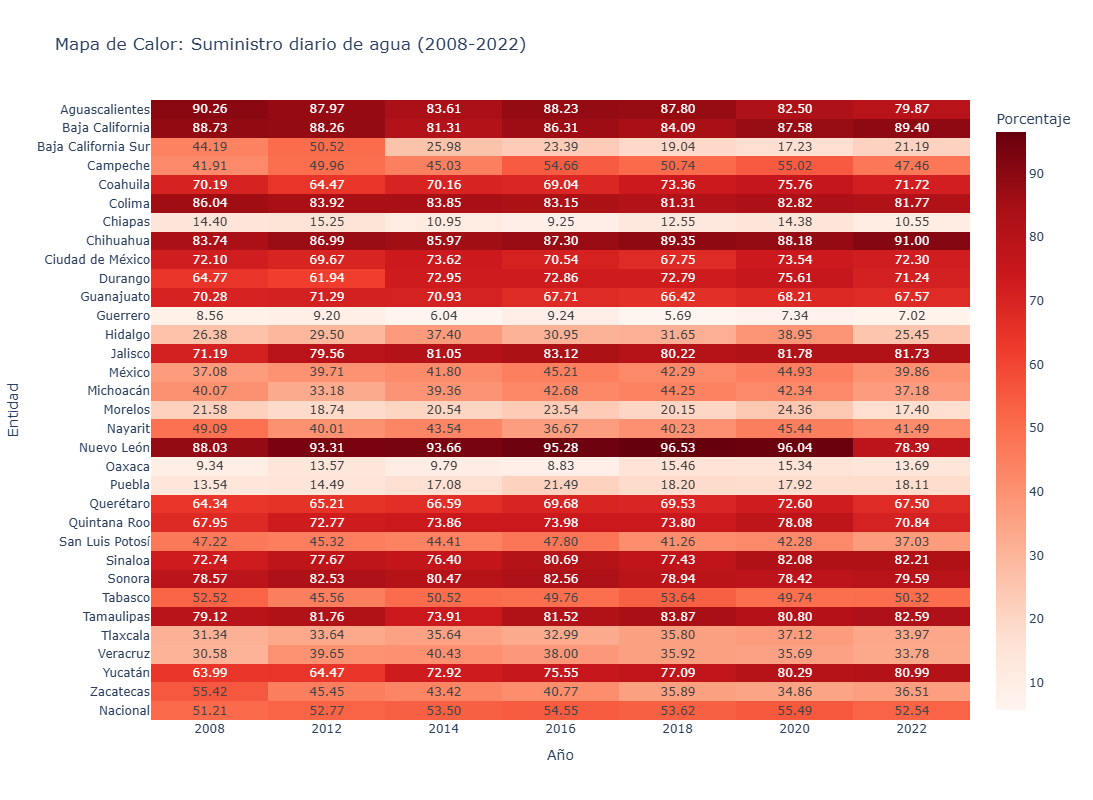

In [162]:
matriz = suministro_total.set_index('Entidad')
fig = px.imshow(
    matriz,
    text_auto='.2f',
    aspect='auto',
    title='Mapa de Calor: Suministro diario de agua (2008-2022)',
    labels=dict(x='Año', y='Entidad', color='Porcentaje'),
    color_continuous_scale='Reds',
    template='plotly_white'
)
fig.write_html('mapa_calor_suministro_diario_agua.html')
fig.update_layout(height=800)
fig.show()